#  Imports

# Les imports 

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import json

#  Charger les données

In [14]:
df = pd.read_parquet("weather.parquet")
print(f"Nombre d'images : {df.shape[0]}")
print(f"Colonnes : {df.columns.tolist()}")
df.head()

Nombre d'images : 6862
Colonnes : ['imagePath', 'fileName', 'label', 'labelId', 'note', 'width', 'height', 'channels', 'features']


,imagePath,fileName,label,labelId,note,width,height,channels,features
0,C:\Users\Sirine\OneDrive - ICT GROUP SAS\Burea...,2208.jpg,dew,0,0.0,64,64,3,"[0.29803923, 0.46666667, 0.003921569, 0.298039..."
1,C:\Users\Sirine\OneDrive - ICT GROUP SAS\Burea...,2209.jpg,dew,0,0.0,64,64,3,"[0.15686275, 0.20392157, 0.11764706, 0.1764706..."
2,C:\Users\Sirine\OneDrive - ICT GROUP SAS\Burea...,2210.jpg,dew,0,0.0,64,64,3,"[0.16470589, 0.23529412, 0.05882353, 0.2705882..."
3,C:\Users\Sirine\OneDrive - ICT GROUP SAS\Burea...,2211.jpg,dew,0,0.0,64,64,3,"[0.0, 0.0627451, 0.0, 0.003921569, 0.07450981,..."
4,C:\Users\Sirine\OneDrive - ICT GROUP SAS\Burea...,2212.jpg,dew,0,0.0,64,64,3,"[0.8392157, 0.89411765, 0.8980392, 0.79607844,..."


# Exploration

Images par catégorie :
label
rime         1160
fogsmog       851
dew           698
sandstorm     692
glaze         639
snow          621
hail          591
rain          526
frost         475
lightning     377
rainbow       232
Name: count, dtype: int64

Nombre de catégories : 11


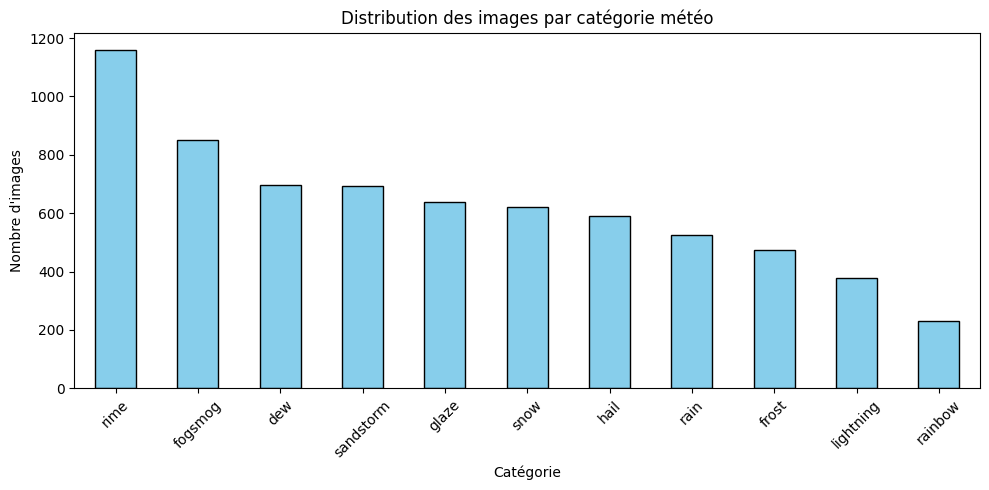

In [15]:
print("Images par catégorie :")
print(df['label'].value_counts())
print(f"\nNombre de catégories : {df['label'].nunique()}")

plt.figure(figsize=(10, 5))
df['label'].value_counts().plot(kind='bar', color='skyblue', edgecolor='black')
plt.title("Distribution des images par catégorie météo")
plt.xlabel("Catégorie")
plt.ylabel("Nombre d'images")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Préparer les données :

In [16]:
X = np.array(df['features'].tolist())
y = df['labelId'].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

X_train_img = X_train.reshape(-1, 64, 64, 3)
X_test_img = X_test.reshape(-1, 64, 64, 3)

X_train_resnet = preprocess_input(X_train_img * 255.0)
X_test_resnet = preprocess_input(X_test_img * 255.0)

num_classes = len(np.unique(y))

print(f"Train : {X_train.shape[0]} images")
print(f"Test  : {X_test.shape[0]} images")
print(f"Shape image : 64x64x3")
print(f"Classes : {num_classes}")

Train : 5489 images
Test  : 1373 images
Shape image : 64x64x3
Classes : 11


# Modèle 1 : CNN simple :

In [17]:
# Modèle 1 : CNN simple
cnn = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(64,64,3)),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(128, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Flatten(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(num_classes, activation='softmax')
])

cnn.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

history_cnn = cnn.fit(X_train_img, y_train, epochs=20, batch_size=32,
                       validation_split=0.2, verbose=1)

cnn_loss, cnn_accuracy = cnn.evaluate(X_test_img, y_test)
print(f"\nAccuracy CNN simple : {cnn_accuracy * 100:.2f}%")

c:\Users\Sirine\OneDrive - ICT GROUP SAS\Bureau\weather-project\venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
138/138 ━━━━━━━━━━━━━━━━━━━━ 9s 51ms/step - accuracy: 0.4042 - loss: 1.7500 - val_accuracy: 0.5464 - val_loss: 1.4222
Epoch 2/20
138/138 ━━━━━━━━━━━━━━━━━━━━ 7s 48ms/step - accuracy: 0.5564 - loss: 1.3298 - val_accuracy: 0.5820 - val_loss: 1.2169
Epoch 3/20
138/138 ━━━━━━━━━━━━━━━━━━━━ 7s 51ms/step - accuracy: 0.6058 - loss: 1.1903 - val_accuracy: 0.5974 - val_loss: 1.2352
Epoch 4/20
138/138 ━━━━━━━━━━━━━━━━━━━━ 7s 49ms/step - accuracy: 0.6251 - loss: 1.1103 - val_accuracy: 0.6457 - val_loss: 1.0669
Epoch 5/20
138/138 ━━━━━━━━━━━━━━━━━━━━ 7s 48ms/step - accuracy: 0.6504 - loss: 1.0336 - val_accuracy: 0.6512 - val_loss: 1.0563
Epoch 6/20
138/138 ━━━━━━━━━━━━━━━━━━━━ 7s 49ms/step - accuracy: 0.6579 - loss: 1.0253 - val_accuracy: 0.6211 - val_loss: 1.1053
Epoch 7/20
138/138 ━━━━━━━━━━━━━━━━━━━━ 7s 49ms/step - accuracy: 0.6659 - loss: 0.9801 - val_accuracy: 0.6566 - val_loss: 1.0032
Epoch 8/20
138/138 ━━━━━━━━━━━━━━━━━━━━ 7s 52ms/step - accuracy: 0.6923 - loss: 0.9072 - val_accu

 # Modèle 2 : ResNet50 (Transfer Learning) :

In [18]:
# Modèle 2 : ResNet50 - Transfer Learning (couches gelées)
base_model1 = ResNet50(weights='imagenet', include_top=False, input_shape=(64, 64, 3))
base_model1.trainable = False

resnet_v1 = models.Sequential([
    base_model1,
    layers.GlobalAveragePooling2D(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(num_classes, activation='softmax')
])

resnet_v1.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

history_v1 = resnet_v1.fit(X_train_resnet, y_train, epochs=20, batch_size=32,
                            validation_split=0.2, verbose=1)

v1_loss, v1_accuracy = resnet_v1.evaluate(X_test_resnet, y_test)
print(f"\nAccuracy CNN simple : {cnn_accuracy * 100:.2f}%")
print(f"Accuracy ResNet v1  : {v1_accuracy * 100:.2f}%")

Epoch 1/20
138/138 ━━━━━━━━━━━━━━━━━━━━ 38s 217ms/step - accuracy: 0.6037 - loss: 1.4354 - val_accuracy: 0.7823 - val_loss: 0.6949
Epoch 2/20
138/138 ━━━━━━━━━━━━━━━━━━━━ 29s 209ms/step - accuracy: 0.7691 - loss: 0.7095 - val_accuracy: 0.7987 - val_loss: 0.6380
Epoch 3/20
138/138 ━━━━━━━━━━━━━━━━━━━━ 29s 212ms/step - accuracy: 0.8158 - loss: 0.5560 - val_accuracy: 0.8097 - val_loss: 0.6081
Epoch 4/20
138/138 ━━━━━━━━━━━━━━━━━━━━ 29s 213ms/step - accuracy: 0.8513 - loss: 0.4465 - val_accuracy: 0.8097 - val_loss: 0.6131
Epoch 5/20
138/138 ━━━━━━━━━━━━━━━━━━━━ 29s 214ms/step - accuracy: 0.8677 - loss: 0.3860 - val_accuracy: 0.8124 - val_loss: 0.6082
Epoch 6/20
138/138 ━━━━━━━━━━━━━━━━━━━━ 30s 214ms/step - accuracy: 0.8848 - loss: 0.3365 - val_accuracy: 0.8179 - val_loss: 0.6096
Epoch 7/20
138/138 ━━━━━━━━━━━━━━━━━━━━ 29s 211ms/step - accuracy: 0.9016 - loss: 0.2894 - val_accuracy: 0.8160 - val_loss: 0.6341
Epoch 8/20
138/138 ━━━━━━━━━━━━━━━━━━━━ 30s 221ms/step - accuracy: 0.9192 - loss: 0

#  Modèle 3 : ResNet50 (Fine-tuning + Data Augmentation) 

In [19]:
# Modèle 3 : ResNet50 - Fine-tuning + Data Augmentation
datagen = ImageDataGenerator(
    rotation_range=40,
    width_shift_range=0.3,
    height_shift_range=0.3,
    horizontal_flip=True,
    zoom_range=0.3,
    brightness_range=[0.7, 1.3],
    shear_range=0.2,
    fill_mode='nearest'
)

base_model2 = ResNet50(weights='imagenet', include_top=False, input_shape=(64, 64, 3))

for layer in base_model2.layers[:-30]:
    layer.trainable = False
for layer in base_model2.layers[-30:]:
    layer.trainable = True

resnet_final = models.Sequential([
    base_model2,
    layers.GlobalAveragePooling2D(),
    layers.Dense(512, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.5),
    layers.Dense(256, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.3),
    layers.Dense(num_classes, activation='softmax')
])

resnet_final.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.00005),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-7)
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

history_final = resnet_final.fit(
    datagen.flow(X_train_resnet, y_train, batch_size=32),
    epochs=40,
    validation_data=(X_test_resnet, y_test),
    callbacks=[reduce_lr, early_stop],
    verbose=1
)

final_loss, final_accuracy = resnet_final.evaluate(X_test_resnet, y_test)
print(f"\nAccuracy CNN simple    : {cnn_accuracy * 100:.2f}%")
print(f"Accuracy ResNet v1     : {v1_accuracy * 100:.2f}%")
print(f"Accuracy ResNet final  : {final_accuracy * 100:.2f}%")

Epoch 1/40
172/172 ━━━━━━━━━━━━━━━━━━━━ 103s 523ms/step - accuracy: 0.2640 - loss: 2.4960 - val_accuracy: 0.5543 - val_loss: 1.4039 - learning_rate: 5.0000e-05
Epoch 2/40
172/172 ━━━━━━━━━━━━━━━━━━━━ 88s 514ms/step - accuracy: 0.5057 - loss: 1.6288 - val_accuracy: 0.6744 - val_loss: 1.0332 - learning_rate: 5.0000e-05
Epoch 3/40
172/172 ━━━━━━━━━━━━━━━━━━━━ 89s 515ms/step - accuracy: 0.5946 - loss: 1.3070 - val_accuracy: 0.7203 - val_loss: 0.8385 - learning_rate: 5.0000e-05
Epoch 4/40
172/172 ━━━━━━━━━━━━━━━━━━━━ 90s 522ms/step - accuracy: 0.6442 - loss: 1.1228 - val_accuracy: 0.7589 - val_loss: 0.7290 - learning_rate: 5.0000e-05
Epoch 5/40
172/172 ━━━━━━━━━━━━━━━━━━━━ 91s 531ms/step - accuracy: 0.6790 - loss: 1.0285 - val_accuracy: 0.7757 - val_loss: 0.6781 - learning_rate: 5.0000e-05
Epoch 6/40
172/172 ━━━━━━━━━━━━━━━━━━━━ 137s 503ms/step - accuracy: 0.6932 - loss: 0.9527 - val_accuracy: 0.7873 - val_loss: 0.6402 - learning_rate: 5.0000e-05
Epoch 7/40
172/172 ━━━━━━━━━━━━━━━━━━━━ 81s 

# Rapport de validation :

In [20]:
# Rapport détaillé du meilleur modèle
y_pred = resnet_final.predict(X_test_resnet)
y_pred_classes = np.argmax(y_pred, axis=1)
label_names = sorted(df['label'].unique())

print("=== RAPPORT DE CLASSIFICATION ===\n")
print(classification_report(y_test, y_pred_classes, target_names=label_names))

43/43 ━━━━━━━━━━━━━━━━━━━━ 13s 253ms/step
=== RAPPORT DE CLASSIFICATION ===

              precision    recall  f1-score   support

         dew       0.94      0.84      0.89       156
     fogsmog       0.92      0.85      0.88       169
       frost       0.61      0.76      0.68        91
       glaze       0.60      0.67      0.64       122
        hail       0.80      0.97      0.88       127
   lightning       0.93      0.99      0.96        80
        rain       0.90      0.89      0.89       105
     rainbow       0.96      0.98      0.97        52
        rime       0.88      0.78      0.82       221
   sandstorm       0.96      0.87      0.91       123
        snow       0.78      0.77      0.77       127

    accuracy                           0.84      1373
   macro avg       0.84      0.85      0.84      1373
weighted avg       0.85      0.84      0.84      1373



# Matrice de confusion :

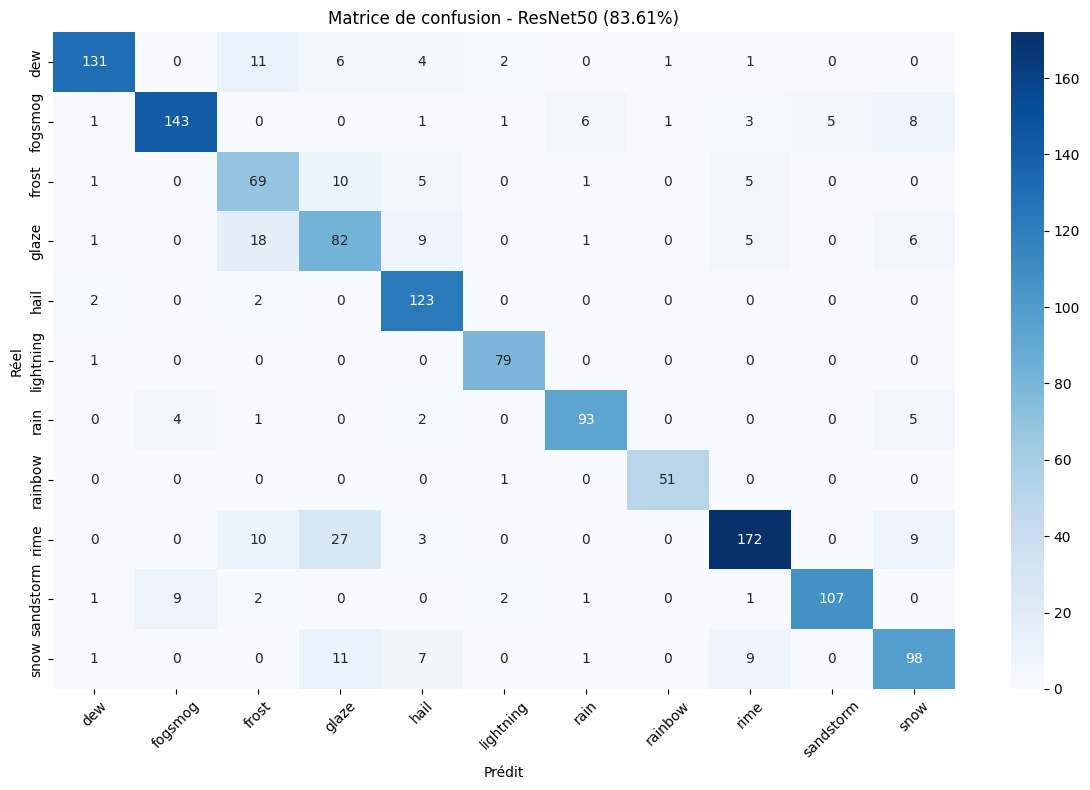

In [21]:
cm = confusion_matrix(y_test, y_pred_classes)
plt.figure(figsize=(12, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_names, yticklabels=label_names)
plt.title(f"Matrice de confusion - ResNet50 ({final_accuracy*100:.2f}%)")
plt.xlabel("Prédit")
plt.ylabel("Réel")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Courbes d'apprentissage :

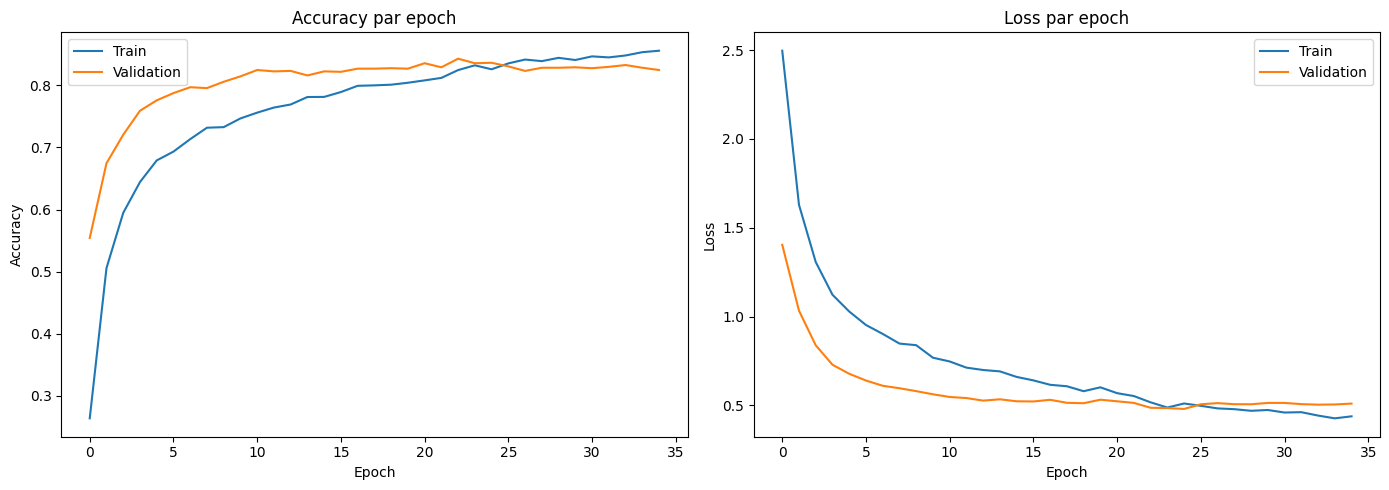

In [22]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(history_final.history['accuracy'], label='Train')
ax1.plot(history_final.history['val_accuracy'], label='Validation')
ax1.set_title("Accuracy par epoch")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Accuracy")
ax1.legend()

ax2.plot(history_final.history['loss'], label='Train')
ax2.plot(history_final.history['val_loss'], label='Validation')
ax2.set_title("Loss par epoch")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Loss")
ax2.legend()

plt.tight_layout()
plt.show()

# Sauvegarder le modèle 

In [23]:
resnet_final.save("resnet_weather_model.keras")

label_mapping = dict(zip(range(len(label_names)), label_names))
with open("label_mapping.json", "w") as f:
    json.dump(label_mapping, f)

print("Modèle sauvegardé : resnet_weather_model.keras")
print("Labels sauvegardés : label_mapping.json")
print(f"Mapping : {label_mapping}")
print(f"Accuracy finale : {final_accuracy * 100:.2f}%")

Modèle sauvegardé : resnet_weather_model.keras
Labels sauvegardés : label_mapping.json
Mapping : {0: 'dew', 1: 'fogsmog', 2: 'frost', 3: 'glaze', 4: 'hail', 5: 'lightning', 6: 'rain', 7: 'rainbow', 8: 'rime', 9: 'sandstorm', 10: 'snow'}
Accuracy finale : 83.61%
